In [3]:
from aspire.samples import PTMCMCSamples
from aspire.utils import AspireFile
from aspire_analysis_tools.utils import compute_rhat
import matplotlib.pyplot as plt
import arviz

In [ ]:
result_files = {
    "gaussian": "/home/michael/git_repos/aspire-analyses/toy_examples/outdir/gaussian_comparison_fixed/15d/aspire_smc_results.h5",
}

Processing results for gaussian...
R-hat for PTMCMC A: [1.0016911  1.00163997 1.00175988 1.00171613 1.0015479  1.00164249
 1.00148265 1.00161255 1.00150169 1.0014182  1.00160516 1.00156059
 1.00148448 1.00174405 1.00188189]
R-hat for PTMCMC B: [1.0008661  1.00094081 1.00095523 1.00106706 1.00093591 1.00085698
 1.00098367 1.00103951 1.0009022  1.00104126 1.00090108 1.00095281
 1.00085495 1.00109508 1.00087297]
R-hat for PTMCMC C (flow): [1.00096045 1.00081821 1.00093905 1.00093977 1.00097291 1.00092106
 1.00086572 1.0009725  1.00093317 1.00090316 1.00093699 1.00086205
 1.00104606 1.00101579 1.00101709]
Beta: 1.0
Beta: 0.5441466148639089
Beta: 0.29609553846785125
Beta: 0.1611193849335876
Beta: 0.0


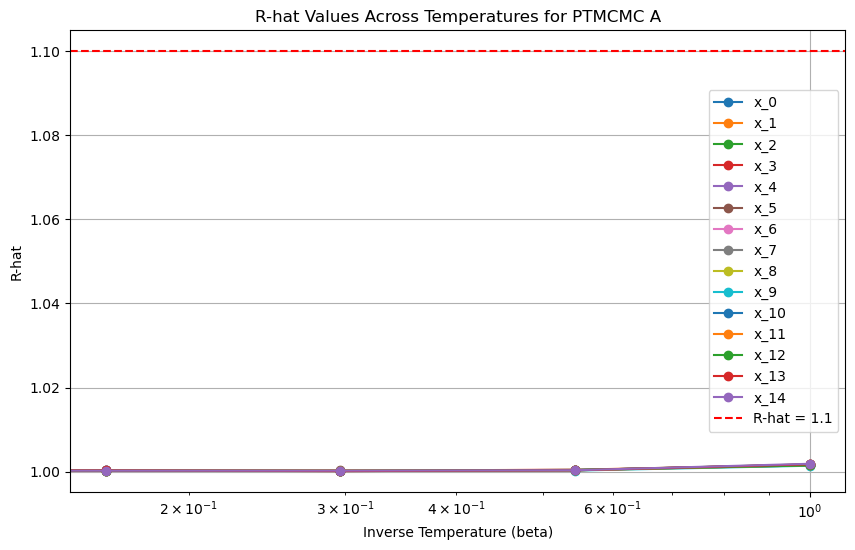

Beta: 1.0
Beta: 0.5441466148639089
Beta: 0.29609553846785125
Beta: 0.1611193849335876
Beta: 0.0876725679005668
Beta: 0.04770673103951964
Beta: 0.025959456201377577
Beta: 0.014125750215687514
Beta: 0.007686479162279495
Beta: 0.004182571616376363
Beta: 0.0022759321864770665
Beta: 0.0012384407949313095
Beta: 0.0006738933662712407
Beta: 0.00036669679403574006
Beta: 0.00019953681915599585
Beta: 0.0


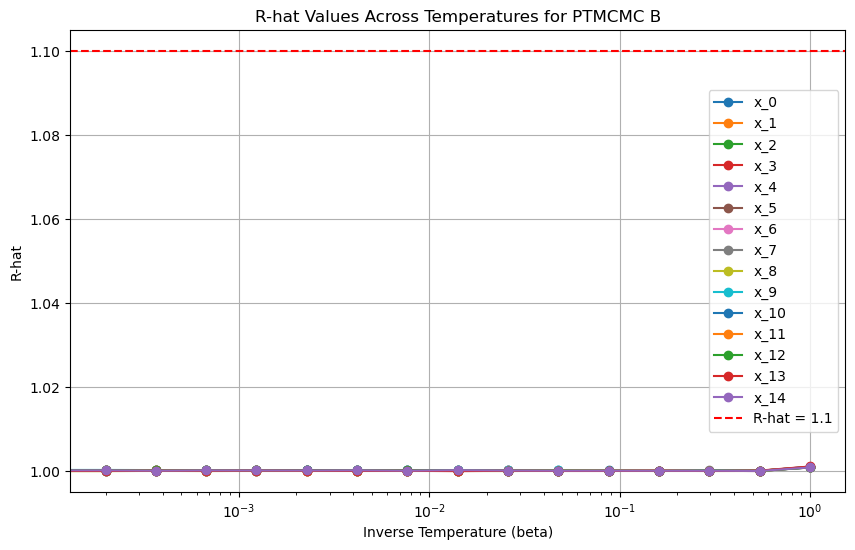

Beta: 1.0
Beta: 0.5441466148639089
Beta: 0.29609553846785125
Beta: 0.1611193849335876
Beta: 0.0876725679005668
Beta: 0.04770673103951964
Beta: 0.025959456201377577
Beta: 0.014125750215687514
Beta: 0.007686479162279495
Beta: 0.004182571616376363
Beta: 0.0022759321864770665
Beta: 0.0012384407949313095
Beta: 0.0006738933662712407
Beta: 0.00036669679403574006
Beta: 0.00019953681915599585
Beta: 0.0


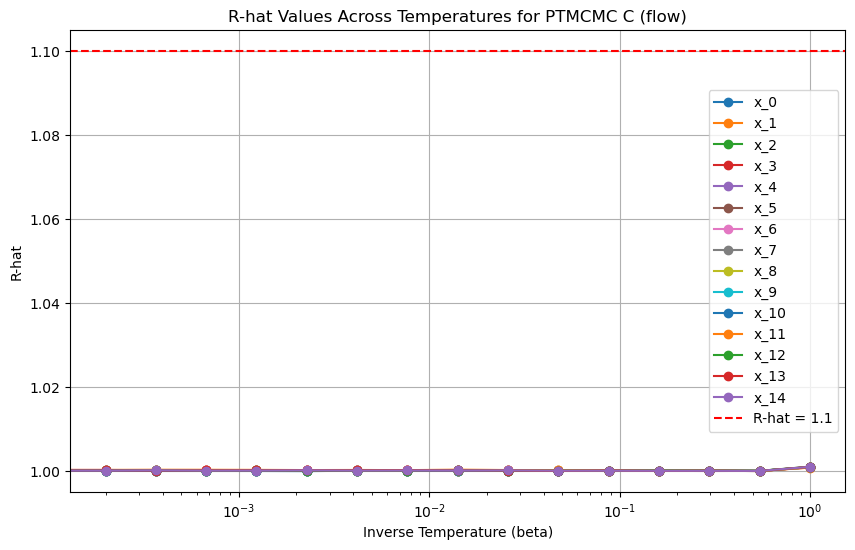

Processing results for multimodal...


KeyError: "Unable to synchronously open object (object 'ptmcmc_samples' doesn't exist)"

In [ ]:
for result_name, result_file in result_files.items():
    with AspireFile(result_file) as f:
        ptmcmc_samples = PTMCMCSamples.load(f, "ptmcmc_samples")
        ptmcmc_samples_alt = PTMCMCSamples.load(f, "ptmcmc_samples_alt")
        ptmcmc_samples_flow = PTMCMCSamples.load(f, "ptmcmc_samples_flow")

    rhat_a = compute_rhat(ptmcmc_samples.cold_chain())
    rhat_b = compute_rhat(ptmcmc_samples_alt.cold_chain())
    rhat_flow = compute_rhat(ptmcmc_samples_flow.cold_chain())

    print(f"R-hat for PTMCMC A: {rhat_a}")
    print(f"R-hat for PTMCMC B: {rhat_b}")
    print(f"R-hat for PTMCMC C (flow): {rhat_flow}")

    for title, chain in zip(
        ["PTMCMC A", "PTMCMC B", "PTMCMC C (flow)"],
        [ptmcmc_samples, ptmcmc_samples_alt, ptmcmc_samples_flow],
    ):
        posterior_chain = chain.cold_chain()
        var_names = posterior_chain.parameters
        # Compute rhat for each temperature

        rhat_values = {}

        for i, beta in enumerate(chain.betas):
            print(f"Beta: {beta}")
            chain_at_temp = chain.at_temperature(i)

            arviz_data = arviz.from_dict(
                {"posterior": chain_at_temp.chain.transpose(1, 0, 2)}
            )
            rhat = arviz.rhat(arviz_data)
            rhat_values[beta] = dict(zip(var_names, rhat["posterior"].values))

        # Plot R-hat values for each parameter across temperatures
        plt.figure(figsize=(10, 6))
        for param in var_names:
            rhat_param = [rhat_values[beta][param] for beta in chain.betas]
            plt.plot(chain.betas, rhat_param, marker="o", label=param)
        plt.axhline(1.1, color="red", linestyle="--", label="R-hat = 1.1")
        plt.xscale("log")
        plt.xlabel("Inverse Temperature (beta)")
        plt.ylabel("R-hat")
        plt.title("R-hat Values Across Temperatures for " + title)
        plt.legend()
        plt.grid()
        plt.show()